<a href="https://colab.research.google.com/github/dataguirre/curso-ia-ciencia-de-datos/blob/main/workshops/05-workshop-ocr-rag-solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para ciencia de datos: Workshop 5 (soluciones)

En el Workshop 4 construimos un RAG sobre los documentos de **Transportes del Llano S.A.S.**, pero hicimos trampa:
los documentos ya venían como texto limpio (`.txt`). En la vida real llegan como **PDF**, y muchas veces como
**PDF escaneado**, que es solo una foto de cada página.

En este workshop vamos a:

1. Distinguir un **PDF nativo** (con capa de texto) de uno **escaneado** (sin texto).
2. Recuperar el texto de los escaneados con **OCR** y **medir** qué tan bien lo hace.
3. Probar si el **preprocesamiento** de la imagen mejora el OCR.
4. Responder la pregunta que importa: **¿el ruido del OCR arruina el RAG?**

Los documentos son una versión extendida de los del Workshop 4: 8 documentos y 50 páginas, con tablas,
encabezados, pies de página y una circular temporal. Tres de ellos también vienen escaneados con tres
niveles de ruido: `limpio`, `leve` y `fuerte`.

> **Antes de empezar:** sube `datos_workshop5.zip` a Colab (panel de archivos, a la izquierda) y agrega tu
> `GROQ_API_KEY` en Secrets, como en el Workshop 2. No hace falta GPU.

### Configuración inicial

Instalamos Tesseract (el motor de OCR) con el paquete de **español**. Sin `tesseract-ocr-spa`, las tildes y
las eñes salen mal y el error se infla artificialmente.

In [ ]:
!apt-get -qq install -y tesseract-ocr tesseract-ocr-spa poppler-utils > /dev/null
!pip install -q pytesseract pdf2image pdfplumber rapidfuzz sentence-transformers faiss-cpu groq

import re
import time
import unicodedata
import zipfile
from pathlib import Path

import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber
import pytesseract
from PIL import Image
from pdf2image import convert_from_path
from rapidfuzz.distance import Levenshtein

print("Tesseract:", pytesseract.get_tesseract_version())
print("Idiomas:", pytesseract.get_languages())

Tesseract: 5.3.4
Idiomas: ['eng', 'osd', 'spa']


In [ ]:
RUTA_ZIP = "datos_workshop5.zip"

with zipfile.ZipFile(RUTA_ZIP) as z:
    z.extractall(".")

DATOS = Path("datos_workshop5")
NIVELES = ["limpio", "leve", "fuerte"]

NATIVOS = sorted((DATOS / "pdf_nativo").glob("*.pdf"))
ESCANEADOS = {nivel: sorted((DATOS / "pdf_escaneado" / nivel).glob("*.pdf")) for nivel in NIVELES}
DOCS_ESCANEADOS = [ruta.stem for ruta in ESCANEADOS["limpio"]]

preguntas = pd.read_csv(DATOS / "preguntas.csv", dtype={"pagina": "Int64"})
preguntas["palabras_clave"] = preguntas["palabras_clave"].fillna("")
preguntas["documento"] = preguntas["documento"].fillna("")

print(f"✓ {len(NATIVOS)} PDF nativos")
for nivel in NIVELES:
    print(f"✓ {len(ESCANEADOS[nivel])} PDF escaneados ({nivel}): {[r.stem for r in ESCANEADOS[nivel]]}")
print(f"✓ {len(preguntas)} preguntas de evaluación")
preguntas.head()

✓ 8 PDF nativos
✓ 3 PDF escaneados (limpio): ['circular_temporada_lluvias_2026', 'politica_mantenimiento', 'tarifas_servicio']
✓ 3 PDF escaneados (leve): ['circular_temporada_lluvias_2026', 'politica_mantenimiento', 'tarifas_servicio']
✓ 3 PDF escaneados (fuerte): ['circular_temporada_lluvias_2026', 'politica_mantenimiento', 'tarifas_servicio']
✓ 15 preguntas de evaluación


,id,pregunta,respuesta_esperada,palabras_clave,documento,pagina,tipo
0,1,¿Cada cuántos kilómetros se hace el mantenimie...,"Cada 10.000 kilómetros o cada tres meses, lo q...",10.000,politica_mantenimiento,5,simple (W4)
1,2,¿Cuál es la profundidad mínima del labrado de ...,3 milímetros.,3,politica_mantenimiento,6,número sensible al OCR
2,3,¿Cuál es el número de la línea de despacho?,"601 555 0147, atiende las 24 horas.",601 555 0147,protocolo_emergencias,3,número sensible al OCR
3,4,¿Cuánto cuesta el flete por tonelada de Yopal ...,"135.000 pesos por tonelada, sin IVA.",135.000,tarifas_servicio,3,tabla
4,6,¿Cuál es la velocidad máxima en la vía Bogotá–...,"60 km/h, por la Circular 07-2026 (vigente del ...",60,circular_temporada_lluvias_2026,1,conflicto temporal


## Actividad 1: ¿Tiene texto o no?

### Objetivo

Un PDF puede verse igual en pantalla y ser dos cosas muy distintas:

- **PDF nativo:** lo generó un programa (Word, un sistema contable). Trae una **capa de texto**: se puede
  seleccionar y copiar. Extraerlo es gratis y exacto.
- **PDF escaneado:** es una **imagen** de cada página. No hay texto que extraer; hay que leerlo con OCR.

Antes de gastar tiempo en OCR, un sistema real debe detectar qué tipo de PDF recibió.

#### Tarea 1: Detectar la capa de texto

Implementa `tiene_capa_texto(ruta, min_caracteres=50)`.

### Requisitos

1. Abre el PDF con `pdfplumber.open(ruta)`.
2. Suma la cantidad de caracteres de `page.extract_text()` de **todas** las páginas, sin contar los espacios
   del inicio y del final. Ojo: `extract_text()` devuelve `None` cuando la página no tiene texto.
3. Devuelve `True` si el total es mayor o igual a `min_caracteres`.

> ¿Por qué un mínimo y no simplemente "mayor que cero"? Algunos escáneres agregan unos pocos caracteres
> (una fecha, un número de lote) aunque el resto de la página sea imagen.

In [ ]:
def tiene_capa_texto(ruta, min_caracteres: int = 50) -> bool:
    """Indica si un PDF tiene una capa de texto aprovechable.

    Args:
        ruta: Ruta al archivo PDF.
        min_caracteres: Mínimo de caracteres para considerar que hay texto.

    Returns:
        True si el PDF tiene al menos min_caracteres de texto extraíble.
    """
    with pdfplumber.open(ruta) as pdf:
        total = sum(len((pagina.extract_text() or "").strip()) for pagina in pdf.pages)

    return total >= min_caracteres

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_tiene_capa_texto():
    if "tiene_capa_texto" not in globals():
        print("✗ Todavía no existe 'tiene_capa_texto'.")
        return

    fallas = []
    try:
        nativos = {r.stem: tiene_capa_texto(r) for r in NATIVOS}
        escaneados = {r.stem: tiene_capa_texto(r) for r in ESCANEADOS["limpio"]}
        exigente = tiene_capa_texto(DATOS / "pdf_nativo" / "circular_temporada_lluvias_2026.pdf",
                                    min_caracteres=1_000_000)
    except Exception as e:
        print(f"✗ tiene_capa_texto lanzó {type(e).__name__}: {e}")
        return

    if all(v is True for v in nativos.values()):
        print(f"✓ detecta texto en los {len(nativos)} PDF nativos")
    else:
        print(f"✗ debería ser True en todos los nativos: {nativos}")
        fallas.append("nativos")

    if all(v is False for v in escaneados.values()):
        print(f"✓ no detecta texto en los {len(escaneados)} PDF escaneados")
    else:
        print(f"✗ debería ser False en todos los escaneados: {escaneados}")
        fallas.append("escaneados")

    if exigente is False:
        print("✓ respeta min_caracteres")
    else:
        print("✗ con min_caracteres=1.000.000 debería devolver False")
        fallas.append("minimo")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_tiene_capa_texto()

✓ detecta texto en los 8 PDF nativos
✓ no detecta texto en los 3 PDF escaneados
✓ respeta min_caracteres

🎉 ¡Todo funciona correctamente!


#### Tarea 2: Extraer el texto de un PDF nativo

Implementa `extraer_paginas_nativo(ruta)`.

### Requisitos

1. Devuelve una `list[str]` con **un elemento por página**, en orden.
2. Si una página no tiene texto, su elemento es `""` (nunca `None`).

Trabajamos **por página** y no con un solo `str` porque en la Actividad 4 queremos saber de qué página salió
cada fragmento, para citar la fuente y para evaluar el retrieval.

In [ ]:
def extraer_paginas_nativo(ruta) -> list[str]:
    """Extrae el texto de cada página de un PDF nativo.

    Args:
        ruta: Ruta al archivo PDF.

    Returns:
        Lista con el texto de cada página.
    """
    with pdfplumber.open(ruta) as pdf:
        return [pagina.extract_text() or "" for pagina in pdf.pages]

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_extraer_paginas_nativo():
    if "extraer_paginas_nativo" not in globals():
        print("✗ Todavía no existe 'extraer_paginas_nativo'.")
        return

    fallas = []
    try:
        manual = extraer_paginas_nativo(DATOS / "pdf_nativo" / "manual_operativo.pdf")
        circular = extraer_paginas_nativo(DATOS / "pdf_nativo" / "circular_temporada_lluvias_2026.pdf")
        escaneado = extraer_paginas_nativo(ESCANEADOS["limpio"][0])
    except Exception as e:
        print(f"✗ extraer_paginas_nativo lanzó {type(e).__name__}: {e}")
        return

    if isinstance(manual, list) and len(manual) == 12:
        print("✓ el manual operativo tiene 12 páginas")
    else:
        print(f"✗ esperaba una lista de 12 páginas, obtuvo {type(manual).__name__} de largo {len(manual)}")
        fallas.append("largo")

    if all(isinstance(p, str) for p in manual + escaneado):
        print("✓ todos los elementos son str (sin None)")
    else:
        print("✗ hay elementos que no son str; cambia None por \"\"")
        fallas.append("tipos")

    if circular and "CIRCULAR OPERATIVA 07-2026" in circular[0]:
        print("✓ el texto de la circular se extrae correctamente")
    else:
        print("✗ la página 1 de la circular debería contener 'CIRCULAR OPERATIVA 07-2026'")
        fallas.append("contenido")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_extraer_paginas_nativo()

✓ el manual operativo tiene 12 páginas
✓ todos los elementos son str (sin None)
✓ el texto de la circular se extrae correctamente

🎉 ¡Todo funciona correctamente!


Extraigamos todos los documentos y miremos una página cualquiera.

In [ ]:
paginas_nativas = {ruta.stem: extraer_paginas_nativo(ruta) for ruta in NATIVOS}

for doc, paginas in paginas_nativas.items():
    print(f"{doc:<35} {len(paginas):>3} páginas  {sum(len(p) for p in paginas):>7,} caracteres")

print("\n" + "=" * 70)
print(paginas_nativas["politica_mantenimiento"][4])

circular_temporada_lluvias_2026       1 páginas    1,463 caracteres
manual_operativo                     12 páginas   23,015 caracteres
politica_mantenimiento                7 páginas   11,035 caracteres
politica_seguridad_vial               7 páginas   10,272 caracteres
politica_viaticos                     6 páginas    7,055 caracteres
protocolo_emergencias                 6 páginas    9,086 caracteres
reglamento_interno                    6 páginas    8,030 caracteres
tarifas_servicio                      5 páginas    6,097 caracteres

TRANSPORTES DEL LLANO S.A.S. MF-002
TL
POLÍTICA DE MANTENIMIENTO DE FLOTA
3. MANTENIMIENTO PREVENTIVO
El mantenimiento preventivo se realiza cada 10.000 kilómetros recorridos o cada tres meses, lo
que ocurra primero. Incluye cambio de aceite de motor y filtros, engrase general y revisión de
correas, mangueras, suspensión y sistema eléctrico. La revisión completa del sistema de frenos
se hace cada 20.000 kilómetros. El coordinador de flota programa los

Fíjate en el inicio y el final de la página: el **encabezado** (nombre de la empresa, título, código) y el
**pie** (`Copia no controlada si se imprime Página 5 de 7`) se repiten en todas las páginas. En el Workshop 4
no existían, porque el texto venía limpio.

Si los dejamos, cada chunk del RAG arrastra ese ruido: el retriever puede preferir un fragmento solo porque
comparte el encabezado con la pregunta, y el LLM recibe texto inútil.

#### Tarea 3: Limpiar encabezados y pies de página

Implementa `limpiar_paginas(paginas, umbral=0.5)`.

La idea es simple: una línea que aparece en la mayoría de las páginas de un documento probablemente es
encabezado o pie, no contenido.

### Requisitos

1. Primero, en cada línea, borra el texto que coincida con el patrón `Página <número> de <número>` y quita
   los espacios del inicio y del final.
2. Si el documento tiene **al menos 3 páginas**, elimina las líneas que aparecen en al menos `umbral` de las
   páginas (cuenta cada línea **una sola vez por página**).
3. Elimina las líneas vacías.
4. Devuelve una lista **del mismo largo** que la entrada; cada página es la unión de sus líneas con `"\n"`.

> Pista: `re.sub(r"Página \d+ de \d+", "", linea)` y `collections.Counter`.

In [ ]:
from collections import Counter

PATRON_PAGINA = re.compile(r"Página \d+ de \d+")


def limpiar_paginas(paginas: list[str], umbral: float = 0.5) -> list[str]:
    """Elimina numeración, encabezados y pies de página repetidos.

    Args:
        paginas: Texto de cada página de un documento.
        umbral: Fracción mínima de páginas en la que debe aparecer una línea para eliminarla.

    Returns:
        Lista con el texto limpio de cada página.
    """
    lineas_por_pagina = [
        [PATRON_PAGINA.sub("", linea).strip() for linea in pagina.splitlines()]
        for pagina in paginas
    ]

    repetidas = set()
    if len(paginas) >= 3:
        conteo = Counter(linea for lineas in lineas_por_pagina for linea in set(lineas) if linea)
        repetidas = {linea for linea, n in conteo.items() if n / len(paginas) >= umbral}

    return [
        "\n".join(linea for linea in lineas if linea and linea not in repetidas)
        for lineas in lineas_por_pagina
    ]

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_limpiar_paginas():
    if "limpiar_paginas" not in globals():
        print("✗ Todavía no existe 'limpiar_paginas'.")
        return

    casos = [
        (
            ["EMPRESA X\nHola mundo\nPie Página 1 de 3",
             "EMPRESA X\nOtra cosa\nPie Página 2 de 3",
             "EMPRESA X\nFinal\n\nPie Página 3 de 3"],
            0.5,
            ["Hola mundo", "Otra cosa", "Final"],
            "quita encabezado, pie y numeración",
        ),
        (
            ["A\nPágina 1 de 2", "A\nB\nPágina 2 de 2"],
            0.5,
            ["A", "A\nB"],
            "con menos de 3 páginas solo quita la numeración",
        ),
        (
            ["X\nuno", "X\ndos", "tres", ""],
            0.5,
            ["uno", "dos", "tres", ""],
            "respeta el umbral y conserva páginas vacías",
        ),
        (
            ["X\nuno", "X\ndos", "tres", ""],
            0.75,
            ["X\nuno", "X\ndos", "tres", ""],
            "con umbral 0.75 la línea X (2 de 4 páginas) se conserva",
        ),
    ]
    fallas = []

    for paginas, umbral, esperado, descripcion in casos:
        try:
            obtenido = limpiar_paginas(paginas, umbral=umbral)
        except Exception as e:
            print(f"✗ lanzó {type(e).__name__}: {e}")
            fallas.append(descripcion)
            continue

        if obtenido == esperado:
            print(f"✓ {descripcion}")
        else:
            print(f"✗ {descripcion}\n    esperaba {esperado}\n    obtuvo   {obtenido}")
            fallas.append(descripcion)

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_limpiar_paginas()

✓ quita encabezado, pie y numeración
✓ con menos de 3 páginas solo quita la numeración
✓ respeta el umbral y conserva páginas vacías
✓ con umbral 0.75 la línea X (2 de 4 páginas) se conserva

🎉 ¡Todo funciona correctamente!


In [ ]:
limpias = limpiar_paginas(paginas_nativas["politica_mantenimiento"])

print(limpias[4])
print("\n" + "=" * 70)
for doc, paginas in paginas_nativas.items():
    antes = sum(len(p) for p in paginas)
    despues = sum(len(p) for p in limpiar_paginas(paginas))
    print(f"{doc:<35} {antes:>7,} → {despues:>7,} caracteres ({1 - despues / antes:.0%} menos)")

3. MANTENIMIENTO PREVENTIVO
El mantenimiento preventivo se realiza cada 10.000 kilómetros recorridos o cada tres meses, lo
que ocurra primero. Incluye cambio de aceite de motor y filtros, engrase general y revisión de
correas, mangueras, suspensión y sistema eléctrico. La revisión completa del sistema de frenos
se hace cada 20.000 kilómetros. El coordinador de flota programa los mantenimientos con base
en el odómetro que reporta el GPS, y el conductor debe llevar el vehículo al taller en la fecha
asignada.
3.1 Intervalos por componente
Además del mantenimiento preventivo general, algunos componentes tienen intervalos propios. El
coordinador de flota los programa para que coincidan, en lo posible, con una visita de
mantenimiento preventivo.
Componente Trabajo Intervalo
Aceite de motor y filtros Cambio En cada mantenimiento preventivo
Sistema de frenos Revisión completa Cada 20.000 kilómetros
Alineación y balanceo Ajuste Cada 30.000 kilómetros
Aceite de caja y de diferencial Cambio Cada 

## Actividad 2: OCR y cómo medirlo

### Objetivo

Recuperar el texto de los PDF escaneados con **Tesseract** y medir su calidad con el
**CER (Character Error Rate)**:

```text
CER = distancia de edición(predicho, referencia) / largo(referencia)
```

La **distancia de edición** (Levenshtein) es la cantidad mínima de caracteres que hay que insertar, borrar o
cambiar para convertir un texto en el otro. Un CER de 0,05 significa que hay un error cada 20 caracteres.

Tenemos una ventaja enorme: cada PDF escaneado tiene su **versión nativa**. El texto nativo de la misma página
es la referencia perfecta.

Primero, veamos cómo se ven los tres niveles de ruido.

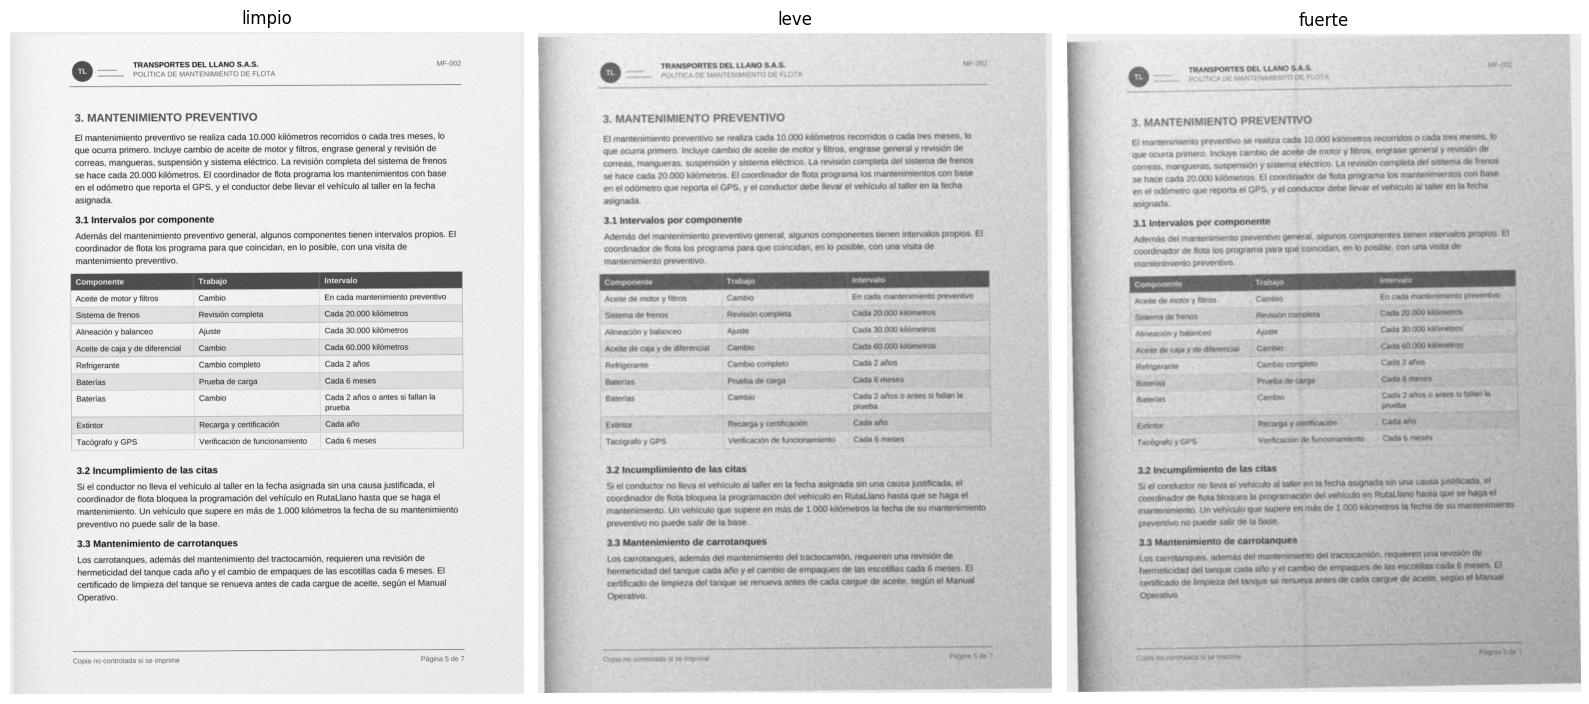

In [ ]:
# @title
fig, ejes = plt.subplots(1, 3, figsize=(16, 7))
for eje, nivel in zip(ejes, NIVELES):
    ruta = DATOS / "pdf_escaneado" / nivel / "politica_mantenimiento.pdf"
    imagen = convert_from_path(ruta, dpi=100, first_page=5, last_page=5)[0]
    eje.imshow(imagen, cmap="gray")
    eje.set_title(nivel)
    eje.axis("off")
plt.tight_layout()
plt.show()

#### Tarea 1: OCR de un PDF

Implementa `ocr_pdf(ruta, dpi=300, idioma="spa", preprocesar=None)`.

### Requisitos

1. Convierte cada página del PDF en imagen con `convert_from_path(ruta, dpi=dpi)`.
2. Si `preprocesar` no es `None`, aplícalo a cada imagen antes del OCR (lo usaremos en la Actividad 3).
3. Aplica `pytesseract.image_to_string(imagen, lang=idioma)` a cada imagen.
4. Devuelve una `list[str]` con un elemento por página.

> Tesseract trabaja mejor alrededor de 300 dpi. Con menos, las letras pequeñas de las tablas se pierden;
> con más, se vuelve lento sin ganar precisión.

In [ ]:
def ocr_pdf(ruta, dpi: int = 300, idioma: str = "spa", preprocesar=None) -> list[str]:
    """Aplica OCR a cada página de un PDF.

    Args:
        ruta: Ruta al archivo PDF.
        dpi: Resolución a la que se convierte cada página en imagen.
        idioma: Idioma de Tesseract.
        preprocesar: Función opcional que recibe y devuelve una imagen PIL.

    Returns:
        Lista con el texto reconocido en cada página.
    """
    textos = []
    for imagen in convert_from_path(ruta, dpi=dpi):
        if preprocesar is not None:
            imagen = preprocesar(imagen)
        textos.append(pytesseract.image_to_string(imagen, lang=idioma))
    return textos

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_ocr_pdf():
    if "ocr_pdf" not in globals():
        print("✗ Todavía no existe 'ocr_pdf'.")
        return

    fallas = []
    llamadas = []

    def _espia(imagen):
        llamadas.append(imagen.size)
        return imagen

    ruta = DATOS / "pdf_escaneado" / "limpio" / "circular_temporada_lluvias_2026.pdf"
    try:
        textos = ocr_pdf(ruta, preprocesar=_espia)
    except Exception as e:
        print(f"✗ ocr_pdf lanzó {type(e).__name__}: {e}")
        return

    if isinstance(textos, list) and len(textos) == 1 and isinstance(textos[0], str):
        print("✓ devuelve una lista con un str por página")
    else:
        print(f"✗ esperaba una lista con 1 str, obtuvo {textos!r:.80}")
        fallas.append("forma")

    if len(llamadas) == 1:
        print("✓ aplica 'preprocesar' a cada página")
    else:
        print(f"✗ 'preprocesar' se llamó {len(llamadas)} veces; esperaba 1")
        fallas.append("preprocesar")

    texto = textos[0].lower() if textos else ""
    if "circular operativa" in texto and "temporada de lluvias" in texto:
        print("✓ el OCR reconoce el texto de la circular")
    else:
        print("✗ el texto no contiene 'circular operativa' ni 'temporada de lluvias'. ¿Usaste lang=idioma?")
        fallas.append("contenido")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")
        print("\nAsí se ve el inicio del OCR:\n")
        print(textos[0][:400])


_validar_ocr_pdf()

✓ devuelve una lista con un str por página
✓ aplica 'preprocesar' a cada página
✓ el OCR reconoce el texto de la circular

🎉 ¡Todo funciona correctamente!

Así se ve el inicio del OCR:

TRANSPORTES DEL LLANO S.A.S.

"NIT 900.555.214-3 - Villavicencio, Meta

ron

CIRCULAR OPERATIVA 07-2026

Fecha: 1 de septiembre de 2026

Para: conductores, despachadores y coordinadores
Asunto: medidas para la segunda temporada de lluvias de 2026

Entre el 15 de septiembre y el 15 de diciembre de 2026 rigen las siguientes medidas
temporales. Mientras dure la temporada, estas medidas prevalecen sob


#### Tarea 2: Calcular el CER

Implementa `calcular_cer(predicho, referencia)`.

### Requisitos

1. **Normaliza** ambos textos: cualquier secuencia de espacios, tabs o saltos de línea se reemplaza por un
   solo espacio, y se quitan los espacios del inicio y del final. Así no castigamos al OCR por cortar las
   líneas en otro lugar.
2. Si la referencia normalizada está vacía, lanza `ValueError`.
3. Devuelve `Levenshtein.distance(predicho, referencia) / len(referencia)`, con los textos ya normalizados.

> Usamos `rapidfuzz` porque calcula la distancia en C. Una implementación en Python puro tardaría varios
> segundos por página.

In [ ]:
def normalizar_espacios(texto: str) -> str:
    """Reemplaza cualquier secuencia de espacios por uno solo y recorta los extremos."""
    return re.sub(r"\s+", " ", texto).strip()


def calcular_cer(predicho: str, referencia: str) -> float:
    """Calcula el Character Error Rate de un texto respecto a su referencia.

    Args:
        predicho: Texto producido por el OCR.
        referencia: Texto correcto.

    Returns:
        Distancia de edición dividida por el largo de la referencia.
    """
    predicho = normalizar_espacios(predicho)
    referencia = normalizar_espacios(referencia)

    if not referencia:
        raise ValueError("La referencia no puede estar vacía")

    return Levenshtein.distance(predicho, referencia) / len(referencia)

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_calcular_cer():
    if "calcular_cer" not in globals():
        print("✗ Todavía no existe 'calcular_cer'.")
        return

    casos = [
        ("hola", "hola", 0.0),
        ("hola  mundo\n", "hola mundo", 0.0),
        ("hxla", "hola", 0.25),
        ("", "abcd", 1.0),
        ("hola mundo!!", "hola mundo", 0.2),
    ]
    fallas = []

    for predicho, referencia, esperado in casos:
        try:
            obtenido = calcular_cer(predicho, referencia)
        except Exception as e:
            print(f"✗ calcular_cer({predicho!r}, {referencia!r}) lanzó {type(e).__name__}: {e}")
            fallas.append("excepción")
            continue

        if abs(obtenido - esperado) < 1e-9:
            print(f"✓ calcular_cer({predicho!r}, {referencia!r}) = {obtenido}")
        else:
            print(f"✗ calcular_cer({predicho!r}, {referencia!r}): esperaba {esperado}, obtuvo {obtenido}")
            fallas.append("valor")

    try:
        calcular_cer("algo", "  \n ")
    except ValueError:
        print("✓ rechaza una referencia vacía")
    except Exception as e:
        print(f"✗ con referencia vacía debería lanzar ValueError, lanzó {type(e).__name__}")
        fallas.append("error")
    else:
        print("✗ con referencia vacía debería lanzar ValueError")
        fallas.append("error")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_calcular_cer()

✓ calcular_cer('hola', 'hola') = 0.0
✓ calcular_cer('hola  mundo\n', 'hola mundo') = 0.0
✓ calcular_cer('hxla', 'hola') = 0.25
✓ calcular_cer('', 'abcd') = 1.0
✓ calcular_cer('hola mundo!!', 'hola mundo') = 0.2
✓ rechaza una referencia vacía

🎉 ¡Todo funciona correctamente!


#### Tarea 3: El experimento

Aplicamos OCR a los 3 documentos escaneados en los 3 niveles de ruido: 39 páginas en total. En Colab tarda
unos minutos; aprovecha para leer lo que sigue.

In [ ]:
ocr = {}

for nivel in NIVELES:
    for ruta in ESCANEADOS[nivel]:
        inicio = time.time()
        ocr[(nivel, ruta.stem)] = ocr_pdf(ruta)
        segundos = time.time() - inicio
        print(f"{nivel:<7} {ruta.stem:<35} {len(ocr[(nivel, ruta.stem)])} páginas en {segundos:5.1f} s")

limpio  circular_temporada_lluvias_2026     1 páginas en   3.0 s
limpio  politica_mantenimiento              7 páginas en  21.6 s
limpio  tarifas_servicio                    5 páginas en  14.0 s
leve    circular_temporada_lluvias_2026     1 páginas en   2.5 s
leve    politica_mantenimiento              7 páginas en  18.6 s
leve    tarifas_servicio                    5 páginas en  12.0 s
fuerte  circular_temporada_lluvias_2026     1 páginas en   3.6 s
fuerte  politica_mantenimiento              7 páginas en  18.6 s
fuerte  tarifas_servicio                    5 páginas en  13.2 s


Ahora comparamos cada página escaneada con la misma página nativa.

Dejamos fuera la **página 2** de los documentos largos: es la tabla de contenido, y sus líneas de puntos
(`. . . . . .`) generan cientos de "errores" que no afectan a nadie. Es un buen recordatorio de que **una métrica
promedio puede engañar**: siempre hay que mirar qué hay detrás del número.

nivel,limpio,leve,fuerte
CER mediano (%),,,
circular_temporada_lluvias_2026,1.0,5.8,52.7
politica_mantenimiento,3.7,9.2,33.0
tarifas_servicio,4.9,7.6,30.2


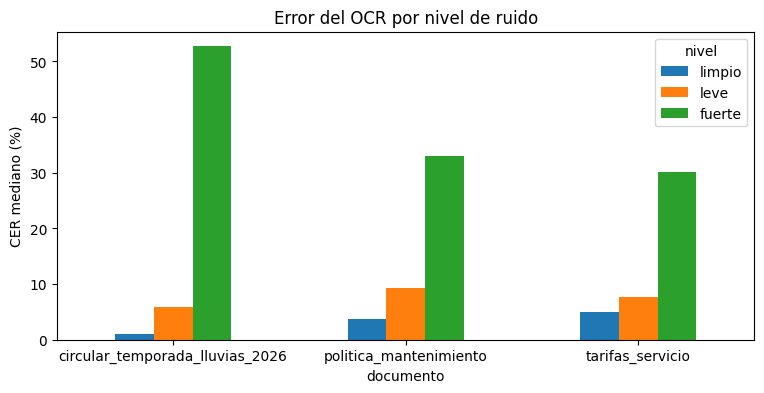

In [ ]:
filas = []
for (nivel, doc), paginas in ocr.items():
    referencias = paginas_nativas[doc]
    for numero, (predicho, referencia) in enumerate(zip(paginas, referencias), start=1):
        filas.append({
            "nivel": nivel,
            "documento": doc,
            "pagina": numero,
            "cer": calcular_cer(predicho, referencia),
            "es_contenido": len(referencias) > 1 and numero == 2,
        })

cer_df = pd.DataFrame(filas)

tabla_cer = (
    cer_df[~cer_df["es_contenido"]]
    .pivot_table(index="documento", columns="nivel", values="cer", aggfunc="median")[NIVELES]
)
display((100 * tabla_cer).round(1).rename_axis("CER mediano (%)"))

(100 * tabla_cer).plot.bar(figsize=(9, 4), rot=0, ylabel="CER mediano (%)",
                           title="Error del OCR por nivel de ruido")
plt.show()

El promedio esconde detalles. Veamos las páginas una por una: ¿cuáles son las peores en el nivel `limpio`?

In [ ]:
display(
    cer_df[cer_df["nivel"] == "limpio"]
    .sort_values("cer", ascending=False)
    .head(5)
    .assign(cer=lambda d: (100 * d["cer"]).round(1))
)

doc, pagina = "politica_mantenimiento", 4
print("=== NATIVO ===")
print(paginas_nativas[doc][pagina - 1][:600])
print("\n=== OCR (limpio) ===")
print(ocr[("limpio", doc)][pagina - 1][:600])

,nivel,documento,pagina,cer,es_contenido
2,limpio,politica_mantenimiento,2,53.9,True
9,limpio,tarifas_servicio,2,37.4,True
4,limpio,politica_mantenimiento,4,11.3,False
3,limpio,politica_mantenimiento,3,6.7,False
12,limpio,tarifas_servicio,5,6.2,False


=== NATIVO ===
TRANSPORTES DEL LLANO S.A.S. MF-002
TL
POLÍTICA DE MANTENIMIENTO DE FLOTA
2.1 Lista de chequeo detallada
Grupo Elemento Qué se revisa Crítico
Motor Aceite de motor Nivel entre las marcas mínima y No
máxima
Motor Refrigerante Nivel y ausencia de fugas No
Motor Correas Tensión y ausencia de grietas No
Llantas Presión Presión según la etiqueta del vehículo Sí
Llantas Estado Cortes, abultamientos y labrado Sí
Frenos Freno de servicio Respuesta del pedal y ausencia de Sí
ruidos
Frenos Freno de parqueo Que sostenga el vehículo en pendiente Sí
Frenos Sistema de aire Presión en el manómetro y purga de

=== OCR (limpio) ===
TRANSPORTES DEL LLANO S.A.S. MF-002
——— POLÍTICA DE MANTENIMIENTO DE FLOTA E

2.1 Lista de chequeo detallada

EX Elemento Qué se revisa Crítico

| Motor Aceite de motor Nivel entre las marcas mínima y
máxima
Motor Refrigerante : | Nivel y ausencia de fugas a No
Motor Correas | : | Tensión y ausencia de grietas INTO
Llantas : Presión - : : | Presión según la et

Incluso con un escaneo limpio, las **tablas** son el punto débil: el encabezado de texto blanco sobre fondo
verde suele desaparecer, y las líneas de la grilla aparecen como `|`.

Pero el CER mide caracteres, y a un sistema le importan los **datos**. Revisemos si algunos datos concretos
sobreviven al OCR en cada nivel.

In [ ]:
DATOS_CLAVE = [
    ("politica_mantenimiento", "cada 10.000 kilómetros"),
    ("politica_mantenimiento", "3 milímetros"),
    ("politica_mantenimiento", "608 555 0275"),
    ("politica_mantenimiento", "110 psi"),
    ("tarifas_servicio", "135.000"),
    ("tarifas_servicio", "400 millones"),
    ("tarifas_servicio", "90.000 pesos"),
    ("circular_temporada_lluvias_2026", "60 km/h"),
    ("circular_temporada_lluvias_2026", "11 toneladas"),
]

supervivencia = pd.DataFrame(
    [
        {
            "documento": doc,
            "dato": dato,
            **{nivel: dato in normalizar_espacios(" ".join(ocr[(nivel, doc)])) for nivel in NIVELES},
        }
        for doc, dato in DATOS_CLAVE
    ]
)
display(supervivencia)
print("Datos encontrados por nivel:", supervivencia[NIVELES].sum().to_dict())

,documento,dato,limpio,leve,fuerte
0,politica_mantenimiento,cada 10.000 kilómetros,True,False,False
1,politica_mantenimiento,3 milímetros,True,False,False
2,politica_mantenimiento,608 555 0275,True,True,False
3,politica_mantenimiento,110 psi,True,False,False
4,tarifas_servicio,135.000,True,True,True
5,tarifas_servicio,400 millones,True,True,True
6,tarifas_servicio,90.000 pesos,True,True,False
7,circular_temporada_lluvias_2026,60 km/h,True,True,False
8,circular_temporada_lluvias_2026,11 toneladas,True,True,True


Datos encontrados por nivel: {'limpio': 9, 'leve': 6, 'fuerte': 3}


### Preguntas para discutir

**1. Un CER de 5 % suena bajo. ¿Es aceptable?**

**R.** Depende de dónde caigan los errores. Una página tiene unos 3.000 caracteres, así que 5 % son unos 150
errores. Si caen en palabras largas, el texto sigue entendiéndose; si caen en un número de teléfono o en un
valor en pesos, el dato queda inservible. Por eso, además del CER, hay que medir la **tarea final**, que es lo
que haremos en la Actividad 4.

**2. ¿Por qué las tablas fallan incluso en el escaneo limpio?**

**R.** Tesseract está pensado para bloques de texto. En una tabla tiene que adivinar cómo agrupar las celdas,
las líneas de la grilla parecen caracteres (`|`) y el texto claro sobre fondo oscuro no se parece a lo que
aprendió a leer. Existen herramientas específicas para tablas, y los VLM que veremos en el Workshop 6 también
lo manejan mejor.

**3. ¿Qué pasaría con `limpiar_paginas` si la aplicáramos al texto del OCR?**

**R.** Funcionaría peor. El encabezado escaneado no sale idéntico en todas las páginas: el ruido cambia un
carácter aquí y allá, y el conteo de líneas exactas ya no lo reconoce como repetido. Alternativas: comparar
líneas con distancia de edición, o recortar la franja del encabezado y el pie **antes** del OCR.

## Actividad 3: Preprocesamiento

### Objetivo

En el nivel `fuerte`, el OCR se equivoca mucho. Mira la imagen: una persona la lee sin problema. ¿Qué está
confundiendo a Tesseract?

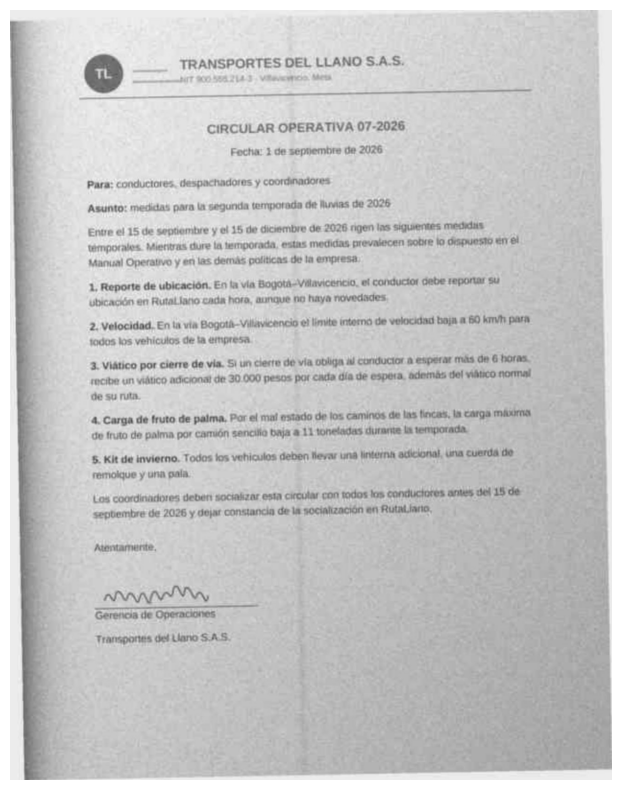

TRANSPORTES DEL LLANO S.A.S.

rr Y O PATAS WAS. MA

CIRCULAR OPERATIVA 07-2026 >
Fecha: 1 de sepyembre de 2026 - |
Para: conductores. despachadores y coordinadores a AE 5 1810)
Asunto: medidas para la segunda temporada de Nuwas de 2026 A p a
po
Ente el 15 de sepúenibre y el 15 de diciembre de 2026 rigen las siguientes meca ds E
a o ¿A
Manual Operativo y en las demás políticas de la empresa. : y Ús Pl
1 epa de iación. En aa Boo Ven, coc ee eo | 7 a
a 0 5 5 5 5 =
todos los vehiculos de la empresa. | INS ES 5 Sed
3, Viktico por cierre de vía. Si un cierto dé vía nblja dl conductor a espárar más de 6 horas
an o cm de
de su ruta. 4 A cea A A JA.

a dc oa rn y HE
de fruto de palma por camión sencillo baja a 11 toneladas durara en Pee AO 7
Air RS hat ana Cue lo ra
remolque y una pala. SA La e xx 


In [ ]:
imagen_fuerte = convert_from_path(
    DATOS / "pdf_escaneado" / "fuerte" / "circular_temporada_lluvias_2026.pdf", dpi=150
)[0]

plt.figure(figsize=(8, 10))
plt.imshow(imagen_fuerte, cmap="gray")
plt.axis("off")
plt.show()

print(ocr[("fuerte", "circular_temporada_lluvias_2026")][0][:800])

El papel es gris, tiene sombra en un borde y la luz baja hacia la derecha. Tesseract binariza la imagen
internamente (la convierte en blanco y negro), y con esa iluminación desigual parte del texto termina
confundido con el fondo: fíjate cómo se pierde el **final de las líneas**.

Vamos a probar tres formas de binarizar la imagen nosotros mismos, antes del OCR.

Todas reciben una imagen PIL (de cualquier modo: RGB o escala de grises) y devuelven una imagen PIL en modo
`"L"` cuyos píxeles valen solo `0` (texto) o `255` (fondo).

#### Tarea 1: Umbral fijo

Implementa `binarizar_fijo(imagen, umbral=150)`.

### Requisitos

1. Convierte la imagen a escala de grises con `imagen.convert("L")` y luego a arreglo con `np.asarray`.
2. Los píxeles **mayores** que `umbral` pasan a 255; el resto, a 0.
3. Devuelve `Image.fromarray(...)` con `dtype=np.uint8`.

In [ ]:
def binarizar_fijo(imagen: Image.Image, umbral: int = 150) -> Image.Image:
    """Binariza una imagen con un umbral fijo."""
    gris = np.asarray(imagen.convert("L"))
    return Image.fromarray(np.where(gris > umbral, 255, 0).astype(np.uint8))

#### Tarea 2: Umbral de Otsu

El umbral fijo tiene un problema: 150 puede ser bueno para una imagen y malo para otra. El método de
**Otsu** elige el umbral automáticamente, buscando el valor que mejor separa los dos grupos de píxeles
(texto y fondo) del histograma.

Implementa `binarizar_otsu(imagen)`.

### Requisitos

1. Convierte la imagen a escala de grises y a arreglo NumPy.
2. Aplica `cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)`. Devuelve una tupla
   `(umbral_elegido, imagen_binaria)`; usa la segunda.
3. Devuelve una imagen PIL.

In [ ]:
def binarizar_otsu(imagen: Image.Image) -> Image.Image:
    """Binariza una imagen eligiendo el umbral con el método de Otsu."""
    gris = np.asarray(imagen.convert("L"))
    _, binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(binaria)

#### Tarea 3: Corregir la iluminación

Otsu usa **un solo umbral para toda la página**. Si un lado de la hoja está más oscuro, ningún umbral único
sirve para los dos lados. La solución clásica es estimar el fondo y dividir por él:

1. Un **filtro de mediana** grande borra las letras (son más delgadas que la ventana) y deja solo la
   iluminación del papel.
2. Dividir la imagen por ese fondo deja el papel parejo, cercano a 255 en toda la hoja.
3. Sobre esa imagen corregida, Otsu ya funciona.

Implementa `corregir_iluminacion(imagen, tamano_fondo=51)`.

### Requisitos

1. Convierte la imagen a escala de grises y a arreglo NumPy.
2. Estima el fondo con `cv2.medianBlur(gris, tamano_fondo)`.
3. Corrige con `cv2.divide(gris, fondo, scale=255)`.
4. Binariza el resultado con Otsu y devuelve una imagen PIL.

In [ ]:
def corregir_iluminacion(imagen: Image.Image, tamano_fondo: int = 51) -> Image.Image:
    """Corrige la iluminación desigual y binariza con Otsu."""
    gris = np.asarray(imagen.convert("L"))
    fondo = cv2.medianBlur(gris, tamano_fondo)
    corregida = cv2.divide(gris, fondo, scale=255)
    _, binaria = cv2.threshold(corregida, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return Image.fromarray(binaria)

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _imagen_con_sombra():
    """Página sintética: fondo que se oscurece hacia la derecha y 'letras' oscuras."""
    alto, ancho = 200, 400
    fondo = np.tile(np.linspace(250, 110, ancho), (alto, 1))
    texto = np.zeros((alto, ancho), dtype=bool)
    for fila in range(20, alto - 20, 30):
        for columna in range(10, ancho - 10, 25):
            texto[fila:fila + 6, columna:columna + 12] = True
    imagen = np.where(texto, fondo * 0.35, fondo).astype(np.uint8)
    return Image.fromarray(imagen).convert("RGB"), texto


def _validar_binarizacion():
    funciones = ["binarizar_fijo", "binarizar_otsu", "corregir_iluminacion"]
    faltan = [f for f in funciones if f not in globals()]
    if faltan:
        print(f"✗ Todavía no existen: {faltan}")
        return

    fallas = []

    # 1. Formato de salida en las tres funciones
    imagen, texto = _imagen_con_sombra()
    salidas = {}
    for nombre in funciones:
        try:
            salida = globals()[nombre](imagen)
        except Exception as e:
            print(f"✗ {nombre} lanzó {type(e).__name__}: {e}")
            fallas.append(nombre)
            continue
        arreglo = np.asarray(salida)
        if isinstance(salida, Image.Image) and salida.mode == "L" and set(np.unique(arreglo)) <= {0, 255}:
            print(f"✓ {nombre} devuelve una imagen 'L' con valores 0 y 255")
            salidas[nombre] = arreglo
        else:
            print(f"✗ {nombre} debe devolver una imagen PIL en modo 'L' con valores 0 y 255")
            fallas.append(nombre)

    # 2. Umbral fijo exacto
    if "binarizar_fijo" in salidas:
        prueba = Image.fromarray(np.array([[0, 150, 151, 255]], dtype=np.uint8))
        obtenido = np.asarray(binarizar_fijo(prueba)).tolist()
        if obtenido == [[0, 0, 255, 255]]:
            print("✓ binarizar_fijo usa 'mayor que' el umbral")
        else:
            print(f"✗ binarizar_fijo([0, 150, 151, 255]) debería dar [0, 0, 255, 255], dio {obtenido}")
            fallas.append("fijo exacto")

    # 3. Otsu separa una imagen con dos tonos
    if "binarizar_otsu" in salidas:
        prueba = Image.fromarray(np.array([[50, 50, 200, 200]] * 4, dtype=np.uint8))
        obtenido = np.asarray(binarizar_otsu(prueba))[0].tolist()
        if obtenido == [0, 0, 255, 255]:
            print("✓ binarizar_otsu separa los dos tonos")
        else:
            print(f"✗ binarizar_otsu debería separar 50 → 0 y 200 → 255, dio {obtenido}")
            fallas.append("otsu")

    # 4. Solo la corrección de iluminación recupera el lado oscuro
    if "corregir_iluminacion" in salidas:
        salida = salidas["corregir_iluminacion"]
        fondo_blanco = (salida[~texto] == 255).mean()
        texto_negro = (salida[texto] == 0).mean()
        if fondo_blanco > 0.95 and texto_negro > 0.9:
            print(f"✓ corregir_iluminacion deja el fondo blanco ({fondo_blanco:.0%}) "
                  f"y el texto negro ({texto_negro:.0%}) en toda la hoja")
        else:
            print(f"✗ con la sombra, el fondo blanco es {fondo_blanco:.0%} y el texto negro {texto_negro:.0%}; "
                  "esperaba más de 95 % y 90 %")
            fallas.append("iluminación")

    if "binarizar_fijo" in salidas:
        print(f"  (como referencia, el umbral fijo deja blanco solo el {(salidas['binarizar_fijo'][~texto] == 255).mean():.0%} "
              "del fondo en esta imagen)")

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_binarizacion()

✓ binarizar_fijo devuelve una imagen 'L' con valores 0 y 255
✓ binarizar_otsu devuelve una imagen 'L' con valores 0 y 255
✓ corregir_iluminacion devuelve una imagen 'L' con valores 0 y 255
✓ binarizar_fijo usa 'mayor que' el umbral
✓ binarizar_otsu separa los dos tonos
✓ corregir_iluminacion deja el fondo blanco (100%) y el texto negro (100%) en toda la hoja
  (como referencia, el umbral fijo deja blanco solo el 71% del fondo en esta imagen)

🎉 ¡Todo funciona correctamente!


#### Tarea 4: ¿Cuál funciona mejor?

Medimos el CER de cuatro páginas de muestra con cada método, en los niveles `leve` y `fuerte`.

Antes de correr la celda, **haz una predicción**: ¿cuál método crees que ganará en cada nivel?

In [ ]:
METODOS = {
    "sin preprocesar": None,
    "umbral fijo": binarizar_fijo,
    "otsu": binarizar_otsu,
    "corregir iluminación": corregir_iluminacion,
}
MUESTRA = [
    ("circular_temporada_lluvias_2026", 1),
    ("politica_mantenimiento", 3),
    ("politica_mantenimiento", 5),
    ("tarifas_servicio", 3),
]

filas = []
for nivel in ["leve", "fuerte"]:
    for doc, pagina in MUESTRA:
        ruta = DATOS / "pdf_escaneado" / nivel / f"{doc}.pdf"
        imagen = convert_from_path(ruta, dpi=300, first_page=pagina, last_page=pagina)[0]
        referencia = paginas_nativas[doc][pagina - 1]
        for metodo, funcion in METODOS.items():
            entrada = imagen if funcion is None else funcion(imagen)
            texto = pytesseract.image_to_string(entrada, lang="spa")
            filas.append({"nivel": nivel, "pagina": f"{doc}:{pagina}", "metodo": metodo,
                          "cer": calcular_cer(texto, referencia)})
    print(f"✓ nivel {nivel} listo")

prepro_df = pd.DataFrame(filas)
display(
    (100 * prepro_df.pivot_table(index=["nivel", "pagina"], columns="metodo", values="cer"))
    .round(1)[list(METODOS)]
)
display(
    (100 * prepro_df.pivot_table(index="nivel", columns="metodo", values="cer", aggfunc="median"))
    .round(1)[list(METODOS)]
    .rename_axis("CER mediano (%)")
)

✓ nivel leve listo
✓ nivel fuerte listo


metodo                                    sin preprocesar  umbral fijo  otsu  \
nivel  pagina                                                                  
fuerte circular_temporada_lluvias_2026:1             52.7         25.2  55.6   
       politica_mantenimiento:3                      27.4         44.7  33.4   
       politica_mantenimiento:5                      47.1         46.6  51.1   
       tarifas_servicio:3                            40.6         44.7  41.9   
leve   circular_temporada_lluvias_2026:1              5.8         10.5   8.3   
       politica_mantenimiento:3                       7.6         24.5  13.0   
       politica_mantenimiento:5                       6.6         20.8  12.4   
       tarifas_servicio:3                             6.9         20.5  14.3   

metodo                                    corregir iluminación  
nivel  pagina                                                   
fuerte circular_temporada_lluvias_2026:1                  15.2  
       politica_mantenimiento:3                           31.6  
       politica_mantenimiento:5                           25.8  
       tarifas_servicio:3                                 32.2  
leve   circular_temporada_lluvias_2026:1                   5.6  
       politica_mantenimiento:3                           12.8  
       politica_mantenimiento:5                           12.9  
       tarifas_servicio:3                                 16.8

metodo,sin preprocesar,umbral fijo,otsu,corregir iluminación
CER mediano (%),,,,
fuerte,43.9,44.7,46.5,28.7
leve,6.8,20.6,12.7,12.9


Mira el resultado con calma, porque no es obvio. En nuestras pruebas pasó esto (CER mediano):

- En el nivel `leve`, **cualquier** preprocesamiento empeora el OCR. Tesseract ya binariza internamente, y
  nuestra binarización convierte el ruido en manchas negras que intenta leer como letras.
- En el nivel `fuerte`, solo la corrección de iluminación ayuda de forma consistente, porque ataca el
  problema real: la sombra.
- El umbral fijo mejora mucho la circular (de 53 % a 25 %) pero empeora otras páginas. Un solo ejemplo
  habría llevado a una conclusión equivocada.

La lección: **el preprocesamiento es una hipótesis, no una receta**. Hay que medirlo en tus propios documentos.

Elige el método que te dio el menor CER mediano en el nivel `fuerte` y aplícalo a los tres documentos. Lo
usaremos como un quinto corpus en la Actividad 4.

In [ ]:
MEJOR_METODO = "corregir iluminación"

for ruta in ESCANEADOS["fuerte"]:
    ocr[("fuerte_pre", ruta.stem)] = ocr_pdf(ruta, preprocesar=METODOS[MEJOR_METODO])
    cers = [
        calcular_cer(p, r)
        for i, (p, r) in enumerate(zip(ocr[("fuerte_pre", ruta.stem)], paginas_nativas[ruta.stem]), start=1)
        if not (len(paginas_nativas[ruta.stem]) > 1 and i == 2)
    ]
    antes = tabla_cer.loc[ruta.stem, "fuerte"]
    print(f"{ruta.stem:<35} CER mediano: {100 * antes:5.1f} % → {100 * np.median(cers):5.1f} %")

circular_temporada_lluvias_2026     CER mediano:  52.7 % →  15.2 %
politica_mantenimiento              CER mediano:  33.0 % →  30.5 %
tarifas_servicio                    CER mediano:  30.2 % →  28.5 %


## Actividad 4: ¿El OCR arruina el RAG?

### Objetivo

Construir el mismo RAG del Workshop 4 sobre cinco versiones del corpus y comparar los resultados:

| Corpus | Cómo se arma |
|---|---|
| `nativo` | Los 8 PDF nativos |
| `limpio`, `leve`, `fuerte` | Los 5 documentos que solo existen en nativo + los 3 escaneados, leídos con OCR en ese nivel |
| `fuerte_pre` | Igual que `fuerte`, pero con el preprocesamiento de la Actividad 3 |

Evaluaremos dos cosas por separado, con las 15 preguntas de `preguntas.csv`:

- **Retrieval:** ¿entre los fragmentos recuperados está la página que contiene la respuesta?
- **Respuesta:** ¿la respuesta del LLM contiene los datos correctos?

### Configuración inicial

Traemos las piezas del Workshop 4 con un cambio: ahora cada chunk es un diccionario que recuerda su
**documento** y su **página**.

In [ ]:
from groq import Groq, RateLimitError
from google.colab import userdata
from sentence_transformers import SentenceTransformer

MODELO_EMBEDDING = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MODELO_GROQ = "openai/gpt-oss-20b"

embedder = SentenceTransformer(MODELO_EMBEDDING)
client = Groq(api_key=userdata.get("GROQ_API_KEY"))


def preguntar_groq(prompt: str, system_prompt: str = None, modelo: str = MODELO_GROQ,
                   temperature: float = 0.0, reintentos: int = 5) -> str:
    """Envía un prompt a Groq y reintenta si se alcanza el límite de uso."""
    mensajes = []
    if system_prompt:
        mensajes.append({"role": "system", "content": system_prompt})
    mensajes.append({"role": "user", "content": prompt})

    for intento in range(reintentos):
        try:
            respuesta = client.chat.completions.create(
                model=modelo,
                messages=mensajes,
                temperature=temperature,
                reasoning_effort="low",
            )
            return respuesta.choices[0].message.content
        except RateLimitError:
            espera = 10 * (intento + 1)
            print(f"  (límite de Groq alcanzado, esperando {espera} s)")
            time.sleep(espera)
    raise RuntimeError("Groq sigue rechazando las solicitudes; espera un minuto y vuelve a intentar.")


def dividir_documento(documento: str, tamano: int = 500) -> list[str]:
    """Divide un texto en fragmentos de aproximadamente tamano caracteres (Workshop 4)."""
    if tamano <= 0:
        raise ValueError("tamano debe ser positivo")
    return [
        documento[i:i + tamano].strip()
        for i in range(0, len(documento), tamano)
        if documento[i:i + tamano].strip()
    ]


def crear_embeddings(textos: list[str]) -> np.ndarray:
    """Convierte textos en embeddings normalizados (Workshop 4)."""
    return embedder.encode(textos, convert_to_numpy=True, normalize_embeddings=True).astype("float32")


def construir_indice(embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Construye un índice FAISS para similitud coseno (Workshop 4)."""
    indice = faiss.IndexFlatIP(embeddings.shape[1])
    indice.add(embeddings)
    return indice


def buscar(pregunta: str, chunks: list[dict], indice: faiss.IndexFlatIP, k: int = 3) -> list[tuple[dict, float]]:
    """Recupera los k chunks más similares a la pregunta, con su similitud."""
    similitudes, posiciones = indice.search(crear_embeddings([pregunta]), min(k, len(chunks)))
    return [(chunks[p], float(s)) for s, p in zip(similitudes[0], posiciones[0]) if p >= 0]


print("✓ Embeddings:", MODELO_EMBEDDING)
print("✓ LLM:", MODELO_GROQ)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
✓ LLM: openai/gpt-oss-20b


#### Tarea 1: Armar el corpus de cada nivel

Implementa `armar_corpus(nivel, paginas_nativas, ocr, documentos_escaneados)`.

### Requisitos

1. Devuelve un diccionario `{documento: lista de páginas}` con **todos** los documentos de `paginas_nativas`.
2. Si `nivel == "nativo"`, usa las páginas de `paginas_nativas` para todos.
3. Si no, los documentos de `documentos_escaneados` usan `ocr[(nivel, documento)]`, y el resto usa
   `paginas_nativas`.
4. Aplica `limpiar_paginas` a las páginas de cada documento.

In [ ]:
def armar_corpus(nivel: str, paginas_nativas: dict, ocr: dict, documentos_escaneados: list[str]) -> dict:
    """Arma el corpus de un nivel, combinando páginas nativas y páginas con OCR.

    Args:
        nivel: "nativo" o el nombre de un nivel de OCR ("limpio", "leve", "fuerte", ...).
        paginas_nativas: {documento: páginas} extraídas de los PDF nativos.
        ocr: {(nivel, documento): páginas} obtenidas con OCR.
        documentos_escaneados: Documentos que tienen versión escaneada.

    Returns:
        {documento: páginas limpias}.
    """
    corpus = {}
    for doc, paginas in paginas_nativas.items():
        if nivel != "nativo" and doc in documentos_escaneados:
            paginas = ocr[(nivel, doc)]
        corpus[doc] = limpiar_paginas(paginas)
    return corpus

#### Tarea 2: Chunks con metadata

Implementa `crear_chunks(corpus, tamano=500)`.

### Requisitos

1. Divide **cada página** por separado con `dividir_documento(pagina, tamano)`. Así ningún chunk mezcla dos
   páginas.
2. Cada chunk es un diccionario `{"texto": ..., "documento": ..., "pagina": ...}`.
3. Las páginas se numeran **desde 1**, como en el PDF.
4. Devuelve una `list[dict]`.

In [ ]:
def crear_chunks(corpus: dict, tamano: int = 500) -> list[dict]:
    """Divide cada página del corpus en chunks que recuerdan su documento y página.

    Args:
        corpus: {documento: páginas}.
        tamano: Tamaño aproximado de cada chunk.

    Returns:
        Lista de chunks con texto, documento y página.
    """
    return [
        {"texto": fragmento, "documento": doc, "pagina": numero}
        for doc, paginas in corpus.items()
        for numero, pagina in enumerate(paginas, start=1)
        for fragmento in dividir_documento(pagina, tamano)
    ]

#### Tarea 3: ¿Acertó el retrieval?

Implementa `acierto_retrieval(resultados, documento, pagina)`.

### Requisitos

1. `resultados` es la salida de `buscar`: una lista de tuplas `(chunk, similitud)`.
2. Devuelve `True` si **alguno** de los chunks tiene ese `documento` y esa `pagina`.

In [ ]:
def acierto_retrieval(resultados: list[tuple[dict, float]], documento: str, pagina: int) -> bool:
    """Indica si algún chunk recuperado viene de la página esperada."""
    return any(
        chunk["documento"] == documento and chunk["pagina"] == pagina
        for chunk, _ in resultados
    )

#### Tarea 4: ¿Acertó la respuesta?

Pedirle a una persona que revise 75 respuestas no escala. Usaremos una evaluación automática simple: cada
pregunta trae `palabras_clave` que una respuesta correcta **debe** contener.

Implementa `contiene_palabras_clave(respuesta, palabras_clave)`.

### Requisitos

1. `palabras_clave` es un `str` con claves separadas por `;`. La respuesta es correcta si contiene **todas**.
2. Las comparaciones ignoran mayúsculas y tildes (usa la función `quitar_tildes`, que ya está escrita).
3. Si una clave es **numérica** (solo dígitos, puntos, comas y espacios), busca en la respuesta los números
   con el patrón `PATRON_NUMERO`, quítales los separadores y compáralos con la clave sin separadores. Así
   `"10.000"`, `"10 000"` y `"10000"` son equivalentes, pero `"100.000"` no.
4. Una clave de texto es correcta si aparece como subcadena.
5. Si `palabras_clave` está vacío, la pregunta no tiene respuesta en los documentos: es correcta solo si la
   respuesta contiene `NO_ENCONTRADO`.

In [ ]:
NO_ENCONTRADO = "No encontré esa información en los documentos"
PATRON_NUMERO = re.compile(r"\d+(?:[.,\s]\d+)*")


def quitar_tildes(texto: str) -> str:
    """Pasa a minúsculas y elimina tildes."""
    return "".join(
        c for c in unicodedata.normalize("NFD", texto.lower())
        if unicodedata.category(c) != "Mn"
    )


def contiene_palabras_clave(respuesta: str, palabras_clave: str) -> bool:
    """Evalúa si una respuesta contiene todas las palabras clave esperadas.

    Args:
        respuesta: Texto generado por el LLM.
        palabras_clave: Claves separadas por ";" (vacío si no hay respuesta en los documentos).

    Returns:
        True si la respuesta es correcta según las claves.
    """
    texto = quitar_tildes(respuesta)
    claves = [c.strip() for c in palabras_clave.split(";") if c.strip()]

    if not claves:
        return quitar_tildes(NO_ENCONTRADO) in texto

    numeros = {re.sub(r"\D", "", n) for n in PATRON_NUMERO.findall(texto)}

    for clave in claves:
        if re.fullmatch(r"[\d.,\s]+", clave):
            if re.sub(r"\D", "", clave) not in numeros:
                return False
        elif quitar_tildes(clave) not in texto:
            return False
    return True

**Evaluación de implementación**

In [ ]:
# @title
# Celda de validación. No modificar.

def _validar_actividad_4():
    funciones = ["armar_corpus", "crear_chunks", "acierto_retrieval", "contiene_palabras_clave"]
    faltan = [f for f in funciones if f not in globals()]
    if faltan:
        print(f"✗ Todavía no existen: {faltan}")
        return

    fallas = []

    def _probar(descripcion, funcion, esperado):
        try:
            obtenido = funcion()
        except Exception as e:
            print(f"✗ {descripcion}: lanzó {type(e).__name__}: {e}")
            fallas.append(descripcion)
            return
        if obtenido == esperado:
            print(f"✓ {descripcion}")
        else:
            print(f"✗ {descripcion}\n    esperaba {esperado!r}\n    obtuvo   {obtenido!r}")
            fallas.append(descripcion)

    nativas = {"a": ["A1"], "b": ["B1", "B2"]}
    ocr_falso = {("leve", "b"): ["b1 ocr", "b2 ocr"]}

    print("armar_corpus")
    _probar("  nativo usa todas las páginas nativas",
            lambda: armar_corpus("nativo", nativas, ocr_falso, ["b"]),
            {"a": ["A1"], "b": ["B1", "B2"]})
    _probar("  un nivel de OCR reemplaza solo los documentos escaneados",
            lambda: armar_corpus("leve", nativas, ocr_falso, ["b"]),
            {"a": ["A1"], "b": ["b1 ocr", "b2 ocr"]})
    _probar("  aplica limpiar_paginas",
            lambda: armar_corpus("nativo", {"c": ["x\nPágina 1 de 1"]}, {}, []),
            {"c": ["x"]})

    print("crear_chunks")
    _probar("  divide por página y numera desde 1",
            lambda: crear_chunks({"d": ["abcde", "", "xy"]}, tamano=3),
            [{"texto": "abc", "documento": "d", "pagina": 1},
             {"texto": "de", "documento": "d", "pagina": 1},
             {"texto": "xy", "documento": "d", "pagina": 3}])

    print("acierto_retrieval")
    resultados = [({"documento": "d", "pagina": 2, "texto": ""}, 0.9),
                  ({"documento": "e", "pagina": 5, "texto": ""}, 0.8)]
    _probar("  encuentra la página correcta", lambda: acierto_retrieval(resultados, "e", 5), True)
    _probar("  documento correcto pero página equivocada", lambda: acierto_retrieval(resultados, "d", 5), False)
    _probar("  lista vacía", lambda: acierto_retrieval([], "d", 2), False)

    print("contiene_palabras_clave")
    casos = [
        ("El mantenimiento es cada 10 000 km.", "10.000", True),
        ("Cada 100.000 km", "10.000", False),
        ("Llame al 608 555 0275.", "608 555 0275", True),
        ("Son 3 milímetros.", "3", True),
        ("Son 13 milímetros.", "3", False),
        ("Debe fotografiarlo y subirlo a rutallano.", "fotograf;RutaLlano", True),
        ("Debe fotografiarlo.", "fotograf;RutaLlano", False),
        ("Máximo 60 km/h hasta el 15 de diciembre de 2026, 60 km/h", "60", True),
        ("No encontré esa información en los documentos.", "", True),
        ("El salario es de 2 millones.", "", False),
        ("CAMIÓN SENCILLO", "camion", True),
    ]
    for respuesta, claves, esperado in casos:
        _probar(f"  {respuesta!r} con {claves!r}", lambda r=respuesta, c=claves: contiene_palabras_clave(r, c), esperado)

    if not fallas:
        print("\n🎉 ¡Todo funciona correctamente!")


_validar_actividad_4()

armar_corpus
✓   nativo usa todas las páginas nativas
✓   un nivel de OCR reemplaza solo los documentos escaneados
✓   aplica limpiar_paginas
crear_chunks
✓   divide por página y numera desde 1
acierto_retrieval
✓   encuentra la página correcta
✓   documento correcto pero página equivocada
✓   lista vacía
contiene_palabras_clave
✓   'El mantenimiento es cada 10 000 km.' con '10.000'
✓   'Cada 100.000 km' con '10.000'
✓   'Llame al 608 555 0275.' con '608 555 0275'
✓   'Son 3 milímetros.' con '3'
✓   'Son 13 milímetros.' con '3'
✓   'Debe fotografiarlo y subirlo a rutallano.' con 'fotograf;RutaLlano'
✓   'Debe fotografiarlo.' con 'fotograf;RutaLlano'
✓   'Máximo 60 km/h hasta el 15 de diciembre de 2026, 60 km/h' con '60'
✓   'No encontré esa información en los documentos.' con ''
✓   'El salario es de 2 millones.' con ''
✓   'CAMIÓN SENCILLO' con 'camion'

🎉 ¡Todo funciona correctamente!


#### Tarea 5: Construir los cinco índices

Con las funciones listas, construimos un índice por corpus.

In [ ]:
CORPUS = ["nativo", "limpio", "leve", "fuerte", "fuerte_pre"]
K = 3

indices = {}
for nivel in CORPUS:
    corpus = armar_corpus(nivel, paginas_nativas, ocr, DOCS_ESCANEADOS)
    chunks = crear_chunks(corpus)
    indices[nivel] = (chunks, construir_indice(crear_embeddings([c["texto"] for c in chunks])))
    print(f"✓ {nivel:<11} {len(chunks):>4} chunks")

✓ nativo       166 chunks
✓ limpio       167 chunks
✓ leve         164 chunks
✓ fuerte       156 chunks
✓ fuerte_pre   163 chunks


#### Tarea 6: Evaluar el retrieval

El retrieval no usa el LLM, así que podemos evaluarlo en los cinco corpus sin gastar llamadas a Groq.

La pregunta 17 no tiene respuesta en los documentos, así que no entra en esta evaluación.

In [ ]:
con_fuente = preguntas[preguntas["documento"] != ""].copy()
con_fuente["escaneado"] = con_fuente["documento"].isin(DOCS_ESCANEADOS)

filas = []
for nivel in CORPUS:
    chunks, indice = indices[nivel]
    for _, p in con_fuente.iterrows():
        resultados = buscar(p["pregunta"], chunks, indice, k=K)
        filas.append({
            "nivel": nivel,
            "id": p["id"],
            "escaneado": p["escaneado"],
            "acierto": acierto_retrieval(resultados, p["documento"], int(p["pagina"])),
        })

retrieval_df = pd.DataFrame(filas)

display(
    retrieval_df.pivot_table(index="escaneado", columns="nivel", values="acierto", aggfunc="mean")[CORPUS]
    .rename(index={True: "respuesta en documento escaneado", False: "respuesta en documento nativo"})
    .map(lambda v: f"{v:.0%}")
)
display(
    retrieval_df.pivot_table(index="id", columns="nivel", values="acierto")[CORPUS]
    .astype(bool)
    .replace({True: "✓", False: "✗"})
)

nivel,nativo,limpio,leve,fuerte,fuerte_pre
escaneado,,,,,
respuesta en documento nativo,100%,100%,100%,100%,100%
respuesta en documento escaneado,90%,90%,100%,60%,50%


nivel,nativo,limpio,leve,fuerte,fuerte_pre
id,,,,,
1,✓,✓,✓,✓,✗
2,✓,✓,✓,✓,✓
3,✓,✓,✓,✓,✓
4,✓,✓,✓,✓,✓
6,✓,✓,✓,✗,✓
7,✗,✗,✓,✗,✗
8,✓,✓,✓,✓,✓
9,✓,✓,✓,✓,✗
13,✓,✓,✓,✓,✓


#### Tarea 7: Evaluar las respuestas

Ahora sí usamos el LLM. Para cuidar el límite gratuito de Groq, evaluamos solo los extremos (`nativo` y
`fuerte`) y el corpus preprocesado: 45 llamadas. Si te sobra cuota, agrega más niveles a `EVALUAR`.

El prompt incluye el documento y la página de cada fragmento, y le pide al modelo una frase exacta cuando no
encuentra la respuesta.

In [ ]:
SYSTEM_PROMPT = (
    "Eres el asistente de Transportes del Llano S.A.S. Responde en español, en una o dos frases, "
    "usando únicamente los fragmentos entregados. Si una circular temporal aplica a la fecha de la "
    "pregunta, prevalece sobre las demás políticas. Si la respuesta no está en los fragmentos, "
    f"responde exactamente: {NO_ENCONTRADO}."
)


def responder_con_rag(pregunta: str, chunks: list[dict], indice, k: int = K) -> tuple[str, list]:
    """Responde con RAG y devuelve también los fragmentos usados."""
    resultados = buscar(pregunta, chunks, indice, k=k)
    contexto = "\n\n".join(
        f"[Fragmento {i} | {c['documento']}, página {c['pagina']}]\n{c['texto']}"
        for i, (c, _) in enumerate(resultados, start=1)
    )
    respuesta = preguntar_groq(f"Fragmentos:\n\n{contexto}\n\nPregunta: {pregunta}",
                               system_prompt=SYSTEM_PROMPT)
    return respuesta, resultados


EVALUAR = ["nativo", "fuerte", "fuerte_pre"]

filas = []
for nivel in EVALUAR:
    chunks, indice = indices[nivel]
    for _, p in preguntas.iterrows():
        respuesta, _ = responder_con_rag(p["pregunta"], chunks, indice)
        filas.append({
            "nivel": nivel,
            "id": p["id"],
            "tipo": p["tipo"],
            "pregunta": p["pregunta"],
            "respuesta": respuesta,
            "esperada": p["respuesta_esperada"],
            "correcta": contiene_palabras_clave(respuesta, p["palabras_clave"]),
        })
        time.sleep(1)
    print(f"✓ {nivel} evaluado")

respuestas_df = pd.DataFrame(filas)
display(respuestas_df.groupby("nivel")["correcta"].mean()[EVALUAR].map(lambda v: f"{v:.0%}").to_frame("aciertos"))
display(
    respuestas_df.pivot_table(index=["id", "tipo"], columns="nivel", values="correcta")[EVALUAR]
    .astype(bool)
    .replace({True: "✓", False: "✗"})
)

✓ nativo evaluado
✓ fuerte evaluado
✓ fuerte_pre evaluado


,aciertos
nivel,
nativo,80%
fuerte,47%
fuerte_pre,40%


,nivel,nativo,fuerte,fuerte_pre
id,tipo,,,
1,simple (W4),✓,✓,✗
2,número sensible al OCR,✓,✓,✓
3,número sensible al OCR,✓,✓,✓
4,tabla,✓,✓,✓
6,conflicto temporal,✓,✗,✗
7,conflicto temporal,✗,✗,✗
8,cálculo,✓,✓,✓
9,cálculo,✓,✗,✗
13,simple (conecta con el VLM),✗,✗,✗


Los porcentajes solo cuentan la mitad de la historia. Lee las respuestas que fallaron: ¿el error viene del
retrieval, del OCR o del LLM? ¿La evaluación automática fue justa o se equivocó?

In [ ]:
pd.set_option("display.max_colwidth", 200)
display(respuestas_df[~respuestas_df["correcta"]][["nivel", "id", "pregunta", "respuesta", "esperada"]])

,nivel,id,pregunta,respuesta,esperada
5,nativo,7,¿Cuántas toneladas de fruto de palma puede llevar un camión sencillo en noviembre de 2026?,12 toneladas.,"11 toneladas, por la Circular 07-2026."
8,nativo,13,¿Qué debe hacer el conductor con el tiquete de báscula de la planta extractora?,No encontré esa información en los documentos.,"Fotografiarlo y subir la foto a RutaLlano antes de salir de la planta, registrar el número de tiquete y el peso neto, y entregar el original en la base en máximo 5 días hábiles."
14,nativo,25,¿Cuánto se factura por llevar 6 toneladas de Puerto Gaitán a Villavicencio?,No encontré esa información en los documentos.,496.000 pesos antes de IVA: se aplica el flete mínimo de 8 toneladas × 62.000.
19,fuerte,6,¿Cuál es la velocidad máxima en la vía Bogotá–Villavicencio en octubre de 2026?,No encontré esa información en los documentos.,"60 km/h, por la Circular 07-2026 (vigente del 15 de septiembre al 15 de diciembre de 2026)."
20,fuerte,7,¿Cuántas toneladas de fruto de palma puede llevar un camión sencillo en noviembre de 2026?,12 toneladas.,"11 toneladas, por la Circular 07-2026."
22,fuerte,9,"Si el camión espera 7 horas y media en el descargue, ¿cuánto se cobra al cliente por tiempo de espera?","Se cobran 3,5 horas × 90 000 pesos = 315 000 pesos.","360.000 pesos: las primeras 4 horas son gratis y se cobran 4 horas (quinta, sexta, séptima y la fracción) × 90.000."
23,fuerte,13,¿Qué debe hacer el conductor con el tiquete de báscula de la planta extractora?,No encontré esa información en los documentos.,"Fotografiarlo y subir la foto a RutaLlano antes de salir de la planta, registrar el número de tiquete y el peso neto, y entregar el original en la base en máximo 5 días hábiles."
26,fuerte,19,¿Cuál es la cobertura máxima del seguro de la carga?,La cobertura máxima del seguro de la carga es de 214.,400 millones de pesos por viaje.
27,fuerte,21,¿Cuál es la presión de referencia del eje delantero de un doble troque?,No encontré esa información en los documentos.,110 psi.
28,fuerte,24,¿Cuál es el teléfono del taller aliado de Puerto Gaitán?,No encontré esa información en los documentos.,608 555 0275.


### Preguntas para discutir

**1. ¿Por qué el retrieval suele resistir mejor el ruido que las respuestas?**

**R.** El embedding de un chunk resume el significado de muchas palabras. Si el OCR daña algunos caracteres,
el vector casi no cambia y el chunk se sigue encontrando. Pero la respuesta depende de datos exactos: basta
un dígito mal leído en `608 555 0275` para que el dato sea inútil, aunque el fragmento sea el correcto. Los
números son a la vez lo más frágil y lo más valioso de estos documentos.

**2. Las preguntas 6 y 7 dependen de la circular. ¿Qué problema muestran y cómo lo resolverías?**

**R.** Hay dos respuestas "correctas" en el corpus: la política general (80 km/h, 12 toneladas) y la circular
temporal (60 km/h, 11 toneladas). El retriever puede traer una, la otra o ambas, y el LLM tiene que decidir.
La solución de fondo es guardar **metadata de vigencia** (fechas de inicio y fin) y filtrar o priorizar según
la fecha de la consulta, en vez de confiar en que el modelo lo deduzca.

**3. Un "PDF nativo" puede traer una capa de texto generada por un OCR malo. ¿Cómo lo detectarías?**

**R.** `tiene_capa_texto` diría que sí tiene texto, así que no basta. Algunas señales: una alta proporción de
palabras que no existen en un diccionario, caracteres extraños, o un CER alto al comparar el texto de una
página con un OCR nuevo de esa misma página. Herramientas como `pdffonts` también muestran fuentes invisibles
que suelen delatar una capa de OCR.

**4. En la Actividad 3, ¿por qué un preprocesamiento puede empeorar el OCR?**

**R.** Tesseract ya binariza internamente con un método razonable. Si nuestra binarización elige mal el
umbral, borra partes de las letras o convierte el ruido en manchas negras, le entregamos una imagen **peor**
que la original. Por eso cada paso de preprocesamiento se debe justificar con una medición.

**5. ¿Cuándo pagarías por algo mejor que Tesseract?**

**R.** Cuando los errores cuestan más que la herramienta: tablas complejas, fotos con perspectiva y sombras,
texto manuscrito, sellos sobre el texto o formularios con campos específicos. Ese es el tema del
Workshop 6, donde usaremos modelos de visión con fotos reales de tiquetes de báscula.

## Extensiones opcionales

- **Recortar antes del OCR:** elimina la franja del encabezado y del pie con `imagen.crop(...)` y compara el
  CER. Así `limpiar_paginas` deja de depender de líneas idénticas.
- **Confianza por palabra:** `pytesseract.image_to_data(..., output_type=pytesseract.Output.DATAFRAME)` entrega
  la confianza de cada palabra. Marca los números con confianza baja para revisión humana.
- **Modo de segmentación:** prueba `config="--psm 4"` o `"--psm 6"` en las páginas con tablas.
- **Enderezar la página:** estima el ángulo con `cv2.minAreaRect` y rota la imagen antes del OCR.
- **Tablas del PDF nativo:** usa `page.extract_tables()` de `pdfplumber` y convierte cada fila en un chunk
  del tipo `"Doble troque — eje delantero: 110 psi"`.
- **Vigencia de la circular:** agrega a cada chunk las fechas de vigencia y filtra por la fecha de la
  pregunta.
- **Corrección con LLM:** pide a Groq que corrija el texto del OCR y mide si el CER baja. Revisa si el
  modelo "corrigió" números que estaban bien.
- **Capa de texto:** herramientas como OCRmyPDF agregan una capa de texto al PDF escaneado, para que después
  se pueda buscar y copiar como uno nativo.

## Resumen

En el Workshop 4 el flujo empezaba con texto limpio:

```text
Texto → chunks → embeddings → búsqueda → LLM → respuesta
```

Ahora empieza con un PDF, que puede o no traer texto:

```text
PDF ─┬─ con capa de texto ──────────────────────┐
     └─ sin capa de texto → imagen → OCR ────────┴→ limpieza → chunks con página → RAG → respuesta
```

Las ideas centrales:

- **Detecta antes de procesar:** si el PDF trae texto, extraerlo es gratis y exacto.
- **Mide el OCR con una referencia**, pero no te quedes solo con el promedio: los datos clave pueden
  romperse aunque el CER sea bajo.
- **El preprocesamiento es una hipótesis** que hay que medir, no una receta.
- **Evalúa la tarea final:** un buen retrieval no garantiza una buena respuesta.